## Import Libraries

First, let's make sure all necessary libraries are imported, including `sklearn` components for preprocessing, model training, and evaluation, as well as `imblearn` for oversampling.

In [26]:
!pip install scikit-optimize optuna scikit-learn --upgrade -q

import warnings, time
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# **Preprocessing (normalization and padding values)**

In [27]:
df = pd.read_csv('/content/drive/MyDrive/HPE DS/CICIDS2017_no_sampling (1).csv')

In [28]:
df.Label.value_counts()

,count
Label,
BENIGN,1841023
DoS,380688
PortScan,158930
Bot,1966
Web Attack � Brute Force,1507
Web Attack � XSS,652
Infiltration,36
Web Attack � Sql Injection,21
Heartbleed,11


In [29]:
# Min-max normalization
numeric_features = df.dtypes[df.dtypes != 'object'].index
df[numeric_features] = df[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max()-x.min()))
# Fill empty values by 0
df = df.fillna(0)

# **split train set and test set**

In [30]:
# Create a temporary DataFrame to work on, dropping rows with NaN in 'Label'
df_temp = df.copy()
df_temp.dropna(subset=['Label'], inplace=True)

labelencoder = LabelEncoder()
# Convert 'Label' column to string type to ensure uniform input for LabelEncoder
df_temp['Label'] = df_temp['Label'].astype(str)
df_temp['Label'] = labelencoder.fit_transform(df_temp['Label'])

X = df_temp.drop(['Label'],axis=1).values
y = df_temp['Label'].values
# Ensure y is explicitly integer type for SMOTE compatibility
y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [31]:
print(dict(zip(labelencoder.classes_, range(len(labelencoder.classes_)))))

{'BENIGN': 0, 'Bot': 1, 'DoS': 2, 'Heartbleed': 3, 'Infiltration': 4, 'PortScan': 5, 'Web Attack � Brute Force': 6, 'Web Attack � Sql Injection': 7, 'Web Attack � XSS': 8}


In [32]:
X_train.shape
pd.Series(y_train).value_counts()

,count
0,1472818
2,304550
5,127144
1,1573
6,1205
8,522
4,29
7,17
3,9


# **Machine learning model training**

Accuracy of XGBoost: 0.9806296871691333
Precision of XGBoost: 0.9946833983167507
Recall of XGBoost: 0.9806296871691333
F1-score of XGBoost: 0.987549592720802
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    368205
           1       0.78      0.61      0.69       393
           2       0.99      0.98      0.99     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.57      0.73         7
           5       0.99      1.00      0.99     31786
           6       0.03      0.19      0.06       302
           7       0.00      0.00      0.00         4
           8       0.00      0.04      0.00       130

    accuracy                           0.98    476967
   macro avg       0.64      0.60      0.60    476967
weighted avg       0.99      0.98      0.99    476967



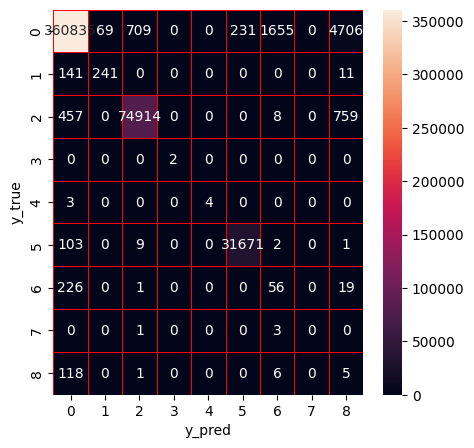

In [33]:
# XGboost training and prediction
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [34]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

# **Feature Selection**

In [35]:
xgb_feature = xg.feature_importances_

In [36]:
feature=(df.drop(['Label'],axis=1)).columns.values
print ("Features sorted by their score:")
print (sorted(zip(map(lambda x: round(x, 4), xgb_feature), feature), reverse=True))

Features sorted by their score:
[(np.float32(0.1639), ' Fwd IAT Max'), (np.float32(0.1256), ' Fwd Packet Length Mean'), (np.float32(0.1132), ' Total Length of Bwd Packets'), (np.float32(0.1094), 'Bwd Packet Length Max'), (np.float32(0.0922), ' Flow IAT Std'), (np.float32(0.0443), 'Fwd Packets/s'), (np.float32(0.0427), ' Init_Win_bytes_backward'), (np.float32(0.0412), ' Flow IAT Min'), (np.float32(0.0352), ' Bwd IAT Max'), (np.float32(0.0333), ' Fwd IAT Std'), (np.float32(0.0311), 'Fwd PSH Flags'), (np.float32(0.0272), ' Bwd IAT Min'), (np.float32(0.0228), ' Idle Max'), (np.float32(0.0227), ' Flow IAT Max'), (np.float32(0.017), ' Average Packet Size'), (np.float32(0.0141), ' Packet Length Mean'), (np.float32(0.0124), 'Fwd IAT Total'), (np.float32(0.0068), ' Bwd Packet Length Std'), (np.float32(0.0056), 'Bwd IAT Total'), (np.float32(0.0051), ' Active Min'), (np.float32(0.0042), ' PSH Flag Count'), (np.float32(0.0041), ' Destination Port'), (np.float32(0.004), 'Init_Win_bytes_forward'), (

In [37]:
f_list = sorted(zip(map(lambda x: round(x, 4), xgb_feature), feature), reverse=True)

In [38]:
len(f_list)

78

In [39]:
# Select the important features from top-importance to bottom-importance until the accumulated importance reaches 0.9 (out of 1)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])
    if Sum>=0.9:
        break

In [40]:
X_fs = df[fs].values

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_fs,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [42]:
X_train.shape

(1907867, 14)

In [43]:
pd.Series(y_train).value_counts()

,count
0,1472818
2,304550
5,127144
1,1573
6,1205
8,522
4,29
7,17
3,9


# **Machine learning model training after feature selection**

Accuracy of XGBoost: 0.9803780974365103
Precision of XGBoost: 0.9837728662214933
Recall of XGBoost: 0.9803780974365103
F1-score of XGBoost: 0.9819999675792026
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    368205
           1       0.68      0.33      0.44       393
           2       0.94      0.95      0.95     76138
           3       1.00      1.00      1.00         2
           4       1.00      0.71      0.83         7
           5       0.99      1.00      0.99     31786
           6       0.21      0.13      0.16       302
           7       0.00      0.00      0.00         4
           8       0.00      0.02      0.00       130

    accuracy                           0.98    476967
   macro avg       0.65      0.57      0.60    476967
weighted avg       0.98      0.98      0.98    476967



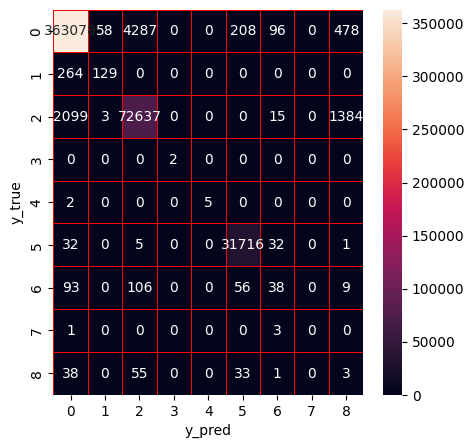

In [44]:
xg = xgb.XGBClassifier(n_estimators = 10)
xg.fit(X_train,y_train)
xg_score=xg.score(X_test,y_test)
y_predict=xg.predict(X_test)
y_true=y_test
print('Accuracy of XGBoost: '+ str(xg_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [45]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

# **Handling imbalance dataset**

In [46]:
# Handle imbalance — compute once, used everywhere
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
print("Sample weights computed. Unique weights:", np.unique(sample_weights).shape[0])

Sample weights computed. Unique weights: 9


Accuracy of XGBoost: 0.9569215480316249
Precision of XGBoost: 0.9820851878559866
Recall of XGBoost: 0.9569215480316249
F1-score of XGBoost: 0.9680722220016059
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    368205
           1       0.05      1.00      0.10       393
           2       0.90      0.99      0.95     76138
           3       1.00      1.00      1.00         2
           4       0.02      0.86      0.03         7
           5       0.99      1.00      1.00     31786
           6       0.06      0.54      0.11       302
           7       0.00      0.00      0.00         4
           8       0.04      0.70      0.08       130

    accuracy                           0.96    476967
   macro avg       0.45      0.78      0.47    476967
weighted avg       0.98      0.96      0.97    476967



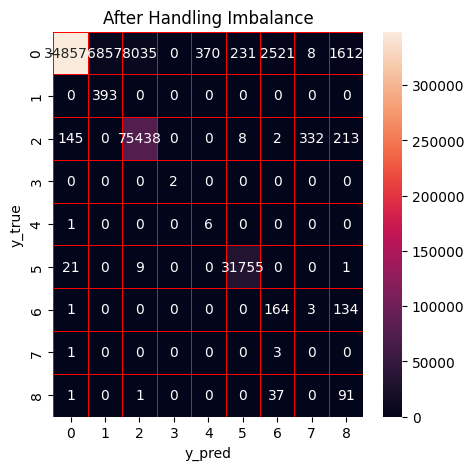

In [47]:
# XGBoost — feature selected + imbalance handled (no tuning yet)
xg_balanced = xgb.XGBClassifier(n_estimators=10, random_state=42)
xg_balanced.fit(X_train, y_train, sample_weight=sample_weights)  # ← this is the actual fix

y_predict = xg_balanced.predict(X_test)
y_true = y_test
print('Accuracy of XGBoost: '+ str(accuracy_score(y_true, y_predict)))
precision,recall,fscore,none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
print('Precision of XGBoost: '+(str(precision)))
print('Recall of XGBoost: '+(str(recall)))
print('F1-score of XGBoost: '+(str(fscore)))
print(classification_report(y_true, y_predict, zero_division=0))
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5,5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred"); plt.ylabel("y_true")
plt.title("After Handling Imbalance")
plt.show()

In [48]:
xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)

# **Hyper Parameter Tuning**

In [49]:
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 7),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 2.0),
        'eval_metric'      : 'mlogloss',
        'random_state'     : 42,
        'n_jobs'           : -1,
        'device'           : 'cuda',   # GPU
        'tree_method'      : 'hist',   # required for GPU
    }

    fold_scores = []
    for train_idx, val_idx in CV.split(X_train, y_train):
        X_fold_train = X_train[train_idx]
        X_fold_val   = X_train[val_idx]
        y_fold_train = y_train[train_idx]
        y_fold_val   = y_train[val_idx]
        w_fold_train = sample_weights[train_idx]

        model = xgb.XGBClassifier(**params)
        model.fit(X_fold_train, y_fold_train, sample_weight=w_fold_train)

        from sklearn.metrics import f1_score
        y_pred = model.predict(X_fold_val)
        score  = f1_score(y_fold_val, y_pred, average='weighted', zero_division=0)
        fold_scores.append(score)

    return np.mean(fold_scores)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5)
)

t0 = time.time()
study.optimize(objective, n_trials=30, show_progress_bar=True)
print(f"\nDone in {time.time()-t0:.1f}s")
print("Best F1 (CV):", round(study.best_value, 4))
print("Best Params:", study.best_params)

  0%|          | 0/30 [00:00<?, ?it/s]


Done in 2284.1s
Best F1 (CV): 0.983
Best Params: {'n_estimators': 445, 'max_depth': 8, 'learning_rate': 0.26262254920547734, 'subsample': 0.8864814810854273, 'colsample_bytree': 0.6662082814499004, 'min_child_weight': 5, 'reg_alpha': 0.01976054591687532, 'reg_lambda': 1.9841918832981724}


Accuracy  : 0.9787
Precision : 0.9879
Recall    : 0.9787
F1-score  : 0.9827
              precision    recall  f1-score   support

           0       1.00      0.97      0.99    368205
           1       0.09      0.98      0.17       393
           2       0.94      0.99      0.97     76138
           3       1.00      1.00      1.00         2
           4       0.35      0.86      0.50         7
           5       0.99      1.00      1.00     31786
           6       0.52      0.70      0.59       302
           7       0.00      0.00      0.00         4
           8       0.07      0.47      0.12       130

    accuracy                           0.98    476967
   macro avg       0.55      0.77      0.59    476967
weighted avg       0.99      0.98      0.98    476967



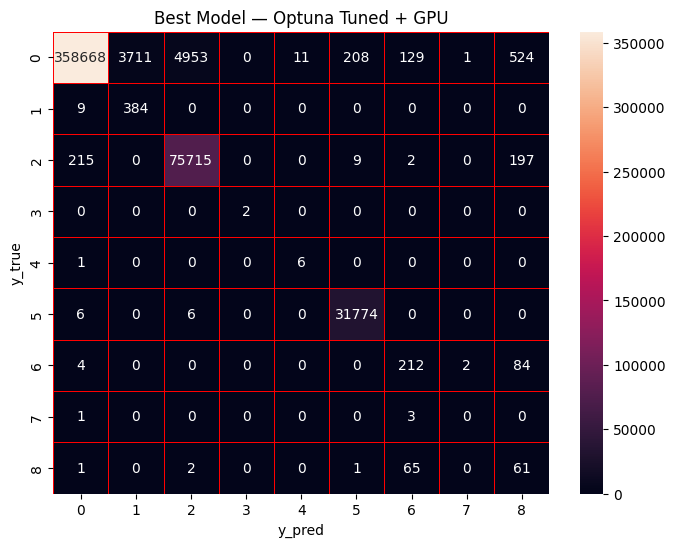

In [50]:
best_model = xgb.XGBClassifier(
    **study.best_params,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    device='cuda',        # GPU
    tree_method='hist',   # required for GPU
)
best_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = best_model.predict(X_test)
precision, recall, fscore, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {fscore:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
f, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', linewidths=.5, linecolor='red', ax=ax)
plt.xlabel("y_pred"); plt.ylabel("y_true")
plt.title("Best Model — Optuna Tuned + GPU")
plt.show()

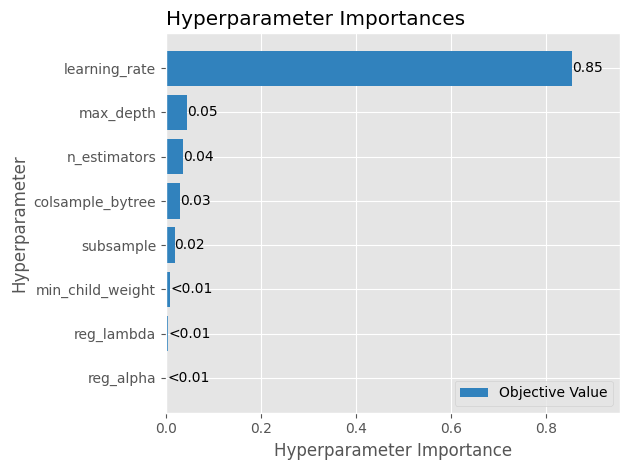

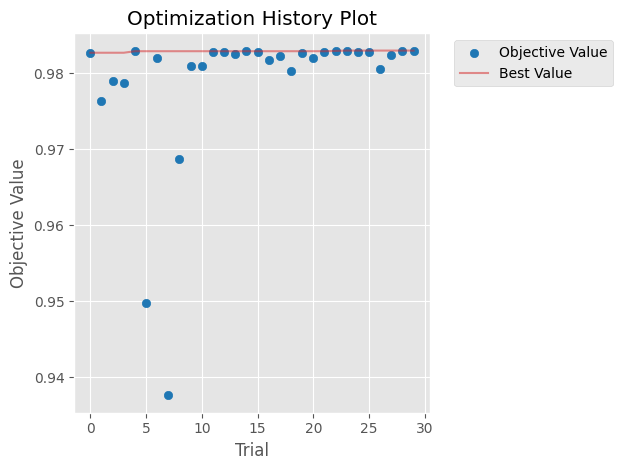

In [51]:
from optuna.visualization.matplotlib import plot_param_importances, plot_optimization_history

plot_param_importances(study)
plt.tight_layout(); plt.show()

plot_optimization_history(study)
plt.tight_layout(); plt.show()